In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("cardio_train.csv", sep=";")

In [4]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0


In [5]:
df.shape

(70000, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


In [7]:
df.isnull().sum()

id             0
age            0
gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
dtype: int64

In [8]:
df.describe()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.sample(1)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
60173,85910,20348,1,164,119.0,180,1000,1,1,0,0,1,1


In [11]:
df['id'].nunique()

70000

In [12]:
df['age'].describe()

count    70000.000000
mean     19468.865814
std       2467.251667
min      10798.000000
25%      17664.000000
50%      19703.000000
75%      21327.000000
max      23713.000000
Name: age, dtype: float64

In [13]:
df['age_years'] = df['age'] / 365.25

In [14]:
df['age_years'].describe()

count    70000.000000
mean        53.302850
std          6.754967
min         29.563313
25%         48.361396
50%         53.943874
75%         58.390144
max         64.922656
Name: age_years, dtype: float64

In [15]:
df['cardio'].value_counts()

cardio
0    35021
1    34979
Name: count, dtype: int64

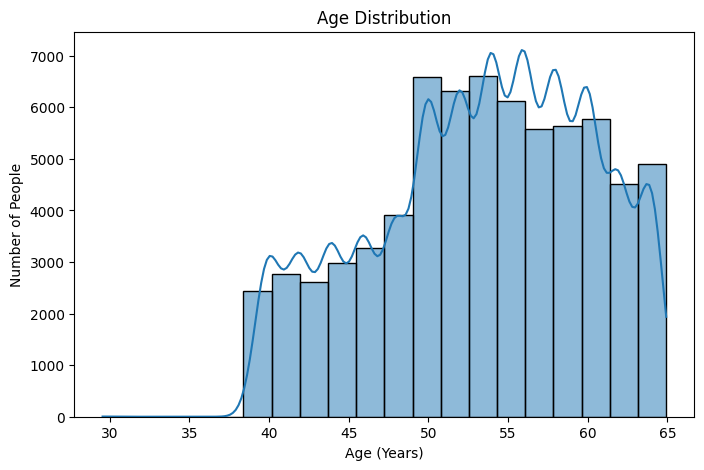

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(df['age_years'], bins=20, kde=True)

plt.xlabel('Age (Years)')
plt.ylabel('Number of People')
plt.title('Age Distribution')

plt.show()

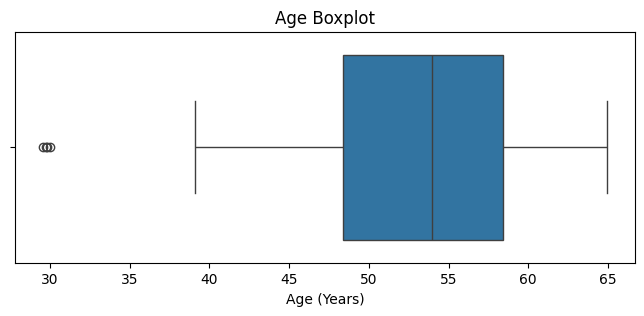

In [18]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=df['age_years'])

plt.xlabel('Age (Years)')
plt.title('Age Boxplot')

plt.show()

In [19]:
df['age_group'] = pd.cut(
    df['age_years'],
    bins=[29, 40, 50, 60, 70],
    labels=['30-40', '40-50', '50-60', '60-70']
)

In [21]:
age_cardio = df.groupby('age_group', observed=True)['cardio'].mean()

age_cardio

age_group
30-40    0.239451
40-50    0.380041
50-60    0.518844
60-70    0.670271
Name: cardio, dtype: float64

<h2>AGE EDA</h2>

<ul>
    <li><strong>Original age:</strong> Stored in <strong>days</strong></li>
    <li><strong>Conversion:</strong> Converted to years using <code>365.25</code></li>
    <li><strong>Mean age:</strong> ≈ <strong>53.3 years</strong></li>
    <li><strong>Age range:</strong> ≈ <strong>29.6–64.9 years</strong></li>
    <li><strong>Distribution:</strong> Roughly bell-shaped</li>
    <li><strong>Potential outliers:</strong> Few observations around 30 years</li>
    <li><strong>Outlier decision:</strong> Retained because these are valid ages</li>
</ul>

<h3>Age vs Cardiovascular Disease</h3>

<p>
Cardiovascular disease prevalence increases strongly with age:
</p>

<table>
    <tr>
        <th>Age Group</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>30–40</td>
        <td><strong>23.95%</strong></td>
    </tr>
    <tr>
        <td>40–50</td>
        <td><strong>38.00%</strong></td>
    </tr>
    <tr>
        <td>50–60</td>
        <td><strong>51.88%</strong></td>
    </tr>
    <tr>
        <td>60–70</td>
        <td><strong>67.03%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
<strong>Older age is strongly associated with higher cardiovascular disease
prevalence in this dataset.</strong>
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [22]:
df['gender'].value_counts()

gender
1    45530
2    24470
Name: count, dtype: int64

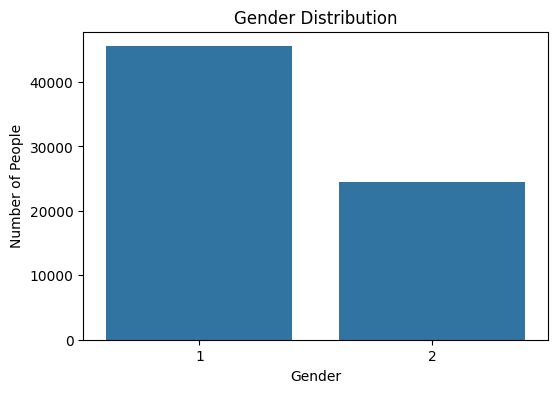

In [23]:
plt.figure(figsize=(6, 4))

sns.countplot(x='gender', data=df)

plt.xlabel('Gender')
plt.ylabel('Number of People')
plt.title('Gender Distribution')

plt.show()

In [24]:
df.groupby('gender')['cardio'].mean()

gender
1    0.496727
2    0.505231
Name: cardio, dtype: float64

<h2>GENDER EDA</h2>

<ul>
    <li><strong>Group 1:</strong> 45,530 (65.04%)</li>
    <li><strong>Group 2:</strong> 24,470 (34.96%)</li>
    <li><strong>Distribution:</strong> The dataset is not gender-balanced.</li>
</ul>

<h3>Gender vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Gender Group</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>Group 1</td>
        <td><strong>49.67%</strong></td>
    </tr>
    <tr>
        <td>Group 2</td>
        <td><strong>50.52%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
The difference in cardiovascular disease prevalence between the two groups
is very small (approximately 0.85 percentage points).
Therefore, gender appears to have a weak individual relationship with
cardiovascular disease in this dataset.
</p>

<p>
<strong>Feature Decision:</strong> Keep the feature for now. Final feature
selection will be decided after model evaluation.
</p>

In [26]:
df['height'].describe()

count    70000.000000
mean       164.359229
std          8.210126
min         55.000000
25%        159.000000
50%        165.000000
75%        170.000000
max        250.000000
Name: height, dtype: float64

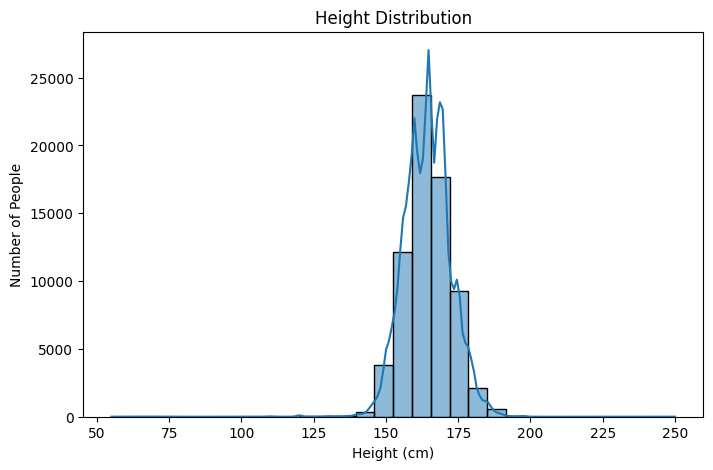

In [27]:
plt.figure(figsize=(8, 5))

sns.histplot(df['height'], bins=30, kde=True)

plt.xlabel('Height (cm)')
plt.ylabel('Number of People')
plt.title('Height Distribution')

plt.show()

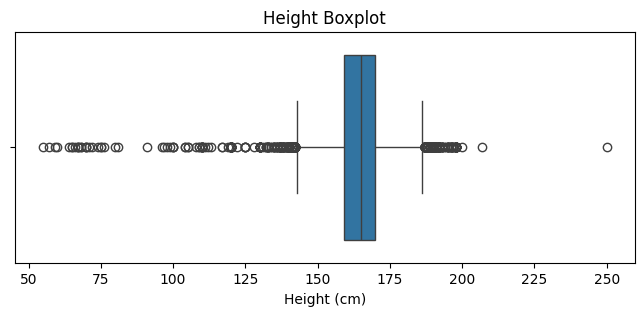

In [28]:
plt.figure(figsize=(8, 3))

sns.boxplot(x=df['height'])

plt.xlabel('Height (cm)')
plt.title('Height Boxplot')

plt.show()

In [29]:
df['height'].sort_values().head(10)

22723    55
66643    57
64115    59
29157    60
27603    64
44490    65
33607    65
64454    66
14323    67
53344    67
Name: height, dtype: int64

In [30]:
df['height'].sort_values(ascending=False).head(10)

6486     250
21628    207
41901    200
8897     198
30127    198
1117     198
57529    198
54289    198
66145    198
3237     198
Name: height, dtype: int64

In [31]:
(df['height'] < 100).sum()

np.int64(29)

In [32]:
(df['height'] > 200).sum()

np.int64(2)

In [33]:
df.groupby(pd.cut(
    df['height'],
    bins=[50, 150, 160, 170, 180, 200, 260]
))['cardio'].mean()

C:\Users\vitta\AppData\Local\Temp\ipykernel_15012\467916817.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(pd.cut(


height
(50, 150]     0.534003
(150, 160]    0.507611
(160, 170]    0.490308
(170, 180]    0.503447
(180, 200]    0.508003
(200, 260]    0.500000
Name: cardio, dtype: float64

<h2>HEIGHT EDA</h2>

<ul>
    <li><strong>Unit:</strong> Centimeters (cm)</li>
    <li><strong>Mean height:</strong> 164.36 cm</li>
    <li><strong>Median height:</strong> 165 cm</li>
    <li><strong>Range:</strong> 55–250 cm</li>
    <li><strong>Distribution:</strong> Roughly bell-shaped</li>
    <li><strong>Most observations:</strong> Concentrated around 160–170 cm</li>
    <li><strong>Potential extreme values:</strong> 29 records below 100 cm and 2 records above 200 cm</li>
    <li><strong>Data quality:</strong> Extreme values may be potential data-quality issues</li>
    <li><strong>Cleaning decision:</strong> No values removed during EDA; treatment will be decided during data cleaning</li>
</ul>

<h3>Height vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Height Range</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>50–150 cm</td>
        <td><strong>53.40%</strong></td>
    </tr>
    <tr>
        <td>150–160 cm</td>
        <td><strong>50.76%</strong></td>
    </tr>
    <tr>
        <td>160–170 cm</td>
        <td><strong>49.03%</strong></td>
    </tr>
    <tr>
        <td>170–180 cm</td>
        <td><strong>50.34%</strong></td>
    </tr>
    <tr>
        <td>180–200 cm</td>
        <td><strong>50.80%</strong></td>
    </tr>
    <tr>
        <td>200–260 cm</td>
        <td><strong>50.00%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Height shows a weak individual relationship with cardiovascular disease
in this dataset. Cardiovascular disease prevalence remains close to
50% across most height groups.
</p>

In [34]:
df['weight'].describe()

count    70000.000000
mean        74.205690
std         14.395757
min         10.000000
25%         65.000000
50%         72.000000
75%         82.000000
max        200.000000
Name: weight, dtype: float64

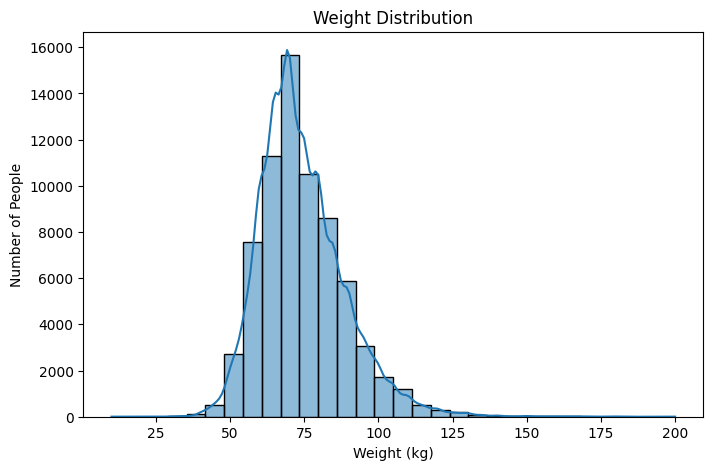

In [35]:
plt.figure(figsize=(8,5))

sns.histplot(df['weight'], bins=30, kde=True)

plt.xlabel('Weight (kg)')
plt.ylabel('Number of People')
plt.title('Weight Distribution')

plt.show()

In [36]:
(df['weight'] < 30).sum()

np.int64(7)

In [37]:
(df['weight'] > 150).sum()

np.int64(59)

In [38]:
weight_cardio = df.groupby(
    pd.cut(
        df['weight'],
        bins=[0, 50, 60, 70, 80, 90, 100, 150, 250]
    )
)['cardio'].mean()

weight_cardio

C:\Users\vitta\AppData\Local\Temp\ipykernel_15012\159246445.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weight_cardio = df.groupby(


weight
(0, 50]       0.287634
(50, 60]      0.383886
(60, 70]      0.444169
(70, 80]      0.515733
(80, 90]      0.586316
(90, 100]     0.649667
(100, 150]    0.692982
(150, 250]    0.627119
Name: cardio, dtype: float64

<h2>WEIGHT EDA</h2>

<ul>
    <li><strong>Unit:</strong> Kilograms (kg)</li>
    <li><strong>Mean weight:</strong> 74.21 kg</li>
    <li><strong>Median weight:</strong> 72 kg</li>
    <li><strong>Standard deviation:</strong> 14.40 kg</li>
    <li><strong>Range:</strong> 10–200 kg</li>
    <li><strong>Distribution:</strong> Mainly concentrated around 50–100 kg and roughly bell-shaped</li>
    <li><strong>Potential extreme values:</strong> 7 records below 30 kg and 59 records above 150 kg</li>
    <li><strong>Extreme values:</strong> Only 66 records (≈0.094%) fall in these extreme ranges</li>
    <li><strong>Cleaning decision:</strong> No values removed during EDA</li>
</ul>

<h3>Weight vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Weight Range</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>0–50 kg</td>
        <td><strong>28.76%</strong></td>
    </tr>
    <tr>
        <td>50–60 kg</td>
        <td><strong>38.39%</strong></td>
    </tr>
    <tr>
        <td>60–70 kg</td>
        <td><strong>44.42%</strong></td>
    </tr>
    <tr>
        <td>70–80 kg</td>
        <td><strong>51.57%</strong></td>
    </tr>
    <tr>
        <td>80–90 kg</td>
        <td><strong>58.63%</strong></td>
    </tr>
    <tr>
        <td>90–100 kg</td>
        <td><strong>64.97%</strong></td>
    </tr>
    <tr>
        <td>100–150 kg</td>
        <td><strong>69.30%</strong></td>
    </tr>
    <tr>
        <td>150–250 kg</td>
        <td><strong>62.71%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Higher weight is strongly associated with higher cardiovascular disease
prevalence in this dataset. The relationship generally increases from
lower to higher weight ranges.
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [39]:
df['ap_hi'].describe()

count    70000.000000
mean       128.817286
std        154.011419
min       -150.000000
25%        120.000000
50%        120.000000
75%        140.000000
max      16020.000000
Name: ap_hi, dtype: float64

In [40]:
df['ap_hi'].sort_values().head(20)

35040   -150
23988   -140
46627   -120
25240   -120
16021   -115
20536   -100
4607    -100
8757       1
42334      1
5382       7
57909     10
2612      10
56777     10
20886     10
62817     10
29170     10
66315     10
6569      11
33103     11
4280      11
Name: ap_hi, dtype: int64

In [41]:
df['ap_hi'].sort_values(ascending=False).head(20)

40852    16020
46912    14020
25519    14020
25464    14020
47253    14020
55847    13010
55459    13010
7763     11500
51438    11020
69370     2000
28147     1620
13895     1500
43208     1420
8915      1420
50836     1409
43133     1400
25780     1400
48795     1400
57291     1300
43504     1300
Name: ap_hi, dtype: int64

In [42]:
(df['ap_hi'] <= 0).sum()

np.int64(7)

In [43]:
(df['ap_hi'] < 60).sum()

np.int64(188)

In [44]:
(df['ap_hi'] > 250).sum()


np.int64(40)

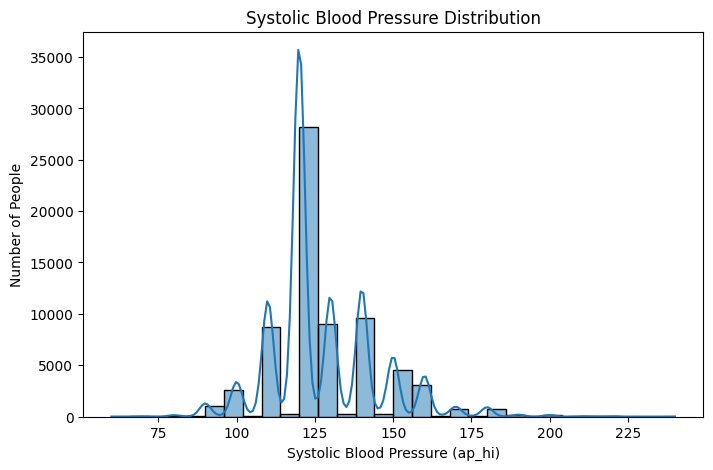

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(
    df.loc[df['ap_hi'].between(60, 250), 'ap_hi'],
    bins=30,
    kde=True
)

plt.xlabel('Systolic Blood Pressure (ap_hi)')
plt.ylabel('Number of People')
plt.title('Systolic Blood Pressure Distribution')

plt.show()

In [46]:
df.groupby(
    pd.cut(df['ap_hi'], bins=[0, 100, 120, 140, 160, 180, 250])
)['cardio'].mean()

C:\Users\vitta\AppData\Local\Temp\ipykernel_15012\1891947355.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


ap_hi
(0, 100]      0.206422
(100, 120]    0.329756
(120, 140]    0.698781
(140, 160]    0.856390
(160, 180]    0.875641
(180, 250]    0.857143
Name: cardio, dtype: float64

In [47]:
df = df[(df['ap_hi'] >= 60) & (df['ap_hi'] <= 250)]

In [48]:
df.shape

(69772, 15)

In [50]:
df.sample(2)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_group
35202,50292,20316,1,165,84.0,130,80,1,1,0,0,1,0,55.622177,50-60
3851,5453,20635,1,168,64.0,120,80,1,1,0,0,0,1,56.495551,50-60


<h2>SYSTOLIC BLOOD PRESSURE (ap_hi) EDA</h2>

<ul>
    <li><strong>Meaning:</strong> Systolic blood pressure, the upper value of a blood pressure reading</li>
    <li><strong>Mean:</strong> 128.82 mmHg</li>
    <li><strong>Median:</strong> 120 mmHg</li>
    <li><strong>Original range:</strong> -150 to 16,020 mmHg</li>
    <li><strong>Distribution:</strong> The main valid range shows a roughly bell-shaped distribution, while extreme values create distortion in the overall distribution</li>
    <li><strong>Invalid/suspicious values:</strong> Values below 60 mmHg and above 250 mmHg were considered unreliable for this dataset</li>
    <li><strong>Rows removed:</strong> 228 records</li>
    <li><strong>Remaining records:</strong> 69,772</li>
</ul>

<h3>Systolic Blood Pressure vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>ap_hi Range (mmHg)</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>0–100</td>
        <td><strong>20.64%</strong></td>
    </tr>
    <tr>
        <td>100–120</td>
        <td><strong>32.98%</strong></td>
    </tr>
    <tr>
        <td>120–140</td>
        <td><strong>69.88%</strong></td>
    </tr>
    <tr>
        <td>140–160</td>
        <td><strong>85.64%</strong></td>
    </tr>
    <tr>
        <td>160–180</td>
        <td><strong>87.56%</strong></td>
    </tr>
    <tr>
        <td>180–250</td>
        <td><strong>85.71%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Systolic blood pressure shows a strong positive association with
cardiovascular disease. Cardio prevalence increases substantially
as systolic blood pressure rises, particularly above 120 mmHg.
</p>

<p>
<strong>Data Cleaning:</strong> Clearly unreliable systolic blood pressure
records were removed before continuing the analysis.
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [51]:
df['ap_lo'].describe()

count    69772.000000
mean        96.641948
std        188.575256
min          0.000000
25%         80.000000
50%         80.000000
75%         90.000000
max      11000.000000
Name: ap_lo, dtype: float64

In [52]:
df['ap_lo'].sort_values().head(20)

65303    0
43922    0
27686    0
13489    0
45835    0
38370    0
16459    0
48049    0
17381    0
56950    0
63787    0
22923    0
35140    1
68568    6
28065    6
19075    7
18898    7
9777     8
7598     8
38599    9
Name: ap_lo, dtype: int64

In [53]:
df['ap_lo'].sort_values(ascending=False).head(20)

43326    11000
23849    10000
2381     10000
68538    10000
43434     9800
6653      9100
32920     9011
12086     9011
15990     8500
44042     8200
20882     8100
37156     8099
38024     8099
17738     8099
23502     8079
63121     8077
2985      8044
9165      8000
37552     8000
14308     7100
Name: ap_lo, dtype: int64

In [54]:
(df['ap_lo'] < 40).sum()

np.int64(47)

In [55]:
(df['ap_lo'] > 150).sum()

np.int64(970)

In [56]:
df.loc[df['ap_lo'] > 150, 'ap_lo'].describe()

count      970.000000
mean      1184.203093
std       1163.210286
min        160.000000
25%       1000.000000
50%       1000.000000
75%       1003.000000
max      11000.000000
Name: ap_lo, dtype: float64

In [57]:
(df['ap_lo'] > 250).sum()

np.int64(950)

In [58]:
df = df[(df['ap_lo'] >= 40) & (df['ap_lo'] <= 250)]

In [59]:
df.shape

(68775, 15)

In [60]:
ap_lo_cardio = df.groupby(
    pd.cut(
        df['ap_lo'],
        bins=[40, 60, 80, 100, 120, 150, 200, 250]
    )
)['cardio'].mean()

ap_lo_cardio

C:\Users\vitta\AppData\Local\Temp\ipykernel_15012\3378168028.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ap_lo_cardio = df.groupby(


ap_lo
(40, 60]      0.245115
(60, 80]      0.392631
(80, 100]     0.762380
(100, 120]    0.811209
(120, 150]    0.862500
(150, 200]    0.850000
(200, 250]         NaN
Name: cardio, dtype: float64

<h2>DIASTOLIC BLOOD PRESSURE (ap_lo) EDA</h2>

<ul>
    <li><strong>Meaning:</strong> Diastolic blood pressure, the lower value of a blood pressure reading</li>
    <li><strong>Mean:</strong> 96.64 mmHg</li>
    <li><strong>Median:</strong> 80 mmHg</li>
    <li><strong>Original range:</strong> 0–11,000 mmHg</li>
    <li><strong>Distribution:</strong> The main valid range is concentrated around typical blood pressure values, while extreme values strongly distort the original distribution</li>
    <li><strong>Potentially invalid values:</strong> 47 records below 40 mmHg and 950 records above 250 mmHg</li>
    <li><strong>Cleaning:</strong> Values below 40 mmHg and above 250 mmHg were removed as highly unreliable</li>
    <li><strong>Rows removed:</strong> 997 records</li>
    <li><strong>Remaining records:</strong> 68,775</li>
</ul>

<h3>Diastolic Blood Pressure vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>ap_lo Range (mmHg)</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>40–60</td>
        <td><strong>24.51%</strong></td>
    </tr>
    <tr>
        <td>60–80</td>
        <td><strong>39.26%</strong></td>
    </tr>
    <tr>
        <td>80–100</td>
        <td><strong>76.24%</strong></td>
    </tr>
    <tr>
        <td>100–120</td>
        <td><strong>81.12%</strong></td>
    </tr>
    <tr>
        <td>120–150</td>
        <td><strong>86.25%</strong></td>
    </tr>
    <tr>
        <td>150–200</td>
        <td><strong>85.00%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Diastolic blood pressure shows a strong positive association with
cardiovascular disease. Cardio prevalence increases substantially
as diastolic blood pressure rises, particularly above 80 mmHg.
</p>

<p>
<strong>Data Cleaning:</strong> Clearly unreliable diastolic blood
pressure values were removed before continuing the analysis.
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [61]:
df.head()

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_group
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0,50.357290,50-60
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1,55.381246,50-60
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1,51.627652,50-60
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1,48.249144,40-50
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0,47.841205,40-50


In [62]:
df['cholesterol'].value_counts().sort_index()

cholesterol
1    51576
2     9313
3     7886
Name: count, dtype: int64

In [63]:
df.groupby('cholesterol')['cardio'].mean()

cholesterol
1    0.435590
2    0.596478
3    0.762871
Name: cardio, dtype: float64

<h2>CHOLESTEROL EDA</h2>

<ul>
    <li><strong>Type:</strong> Ordinal categorical feature</li>
    <li><strong>Categories:</strong> 1, 2, and 3</li>
    <li><strong>Category 1:</strong> 51,576 records (74.99%)</li>
    <li><strong>Category 2:</strong> 9,313 records (13.54%)</li>
    <li><strong>Category 3:</strong> 7,886 records (11.47%)</li>
    <li><strong>Missing values:</strong> None</li>
</ul>

<h3>Cholesterol vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Cholesterol Category</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>1</td>
        <td><strong>43.56%</strong></td>
    </tr>
    <tr>
        <td>2</td>
        <td><strong>59.65%</strong></td>
    </tr>
    <tr>
        <td>3</td>
        <td><strong>76.29%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Cardiovascular disease prevalence increases substantially across
cholesterol categories. Category 3 has the highest cardio prevalence,
followed by category 2 and category 1.
</p>

<p>
<strong>Conclusion:</strong> Cholesterol appears to be an important
predictive feature for cardiovascular disease in this dataset.
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [64]:
df['gluc'].value_counts().sort_index()

gluc
1    58466
2     5074
3     5235
Name: count, dtype: int64

In [65]:
df.groupby('gluc')['cardio'].mean()

gluc
1    0.475678
2    0.588687
3    0.618720
Name: cardio, dtype: float64

<h2>GLUCOSE (gluc) EDA</h2>

<ul>
    <li><strong>Type:</strong> Ordinal categorical feature</li>
    <li><strong>Categories:</strong> 1, 2, and 3</li>
    <li><strong>Category 1:</strong> 58,466 records (85.01%)</li>
    <li><strong>Category 2:</strong> 5,074 records (7.38%)</li>
    <li><strong>Category 3:</strong> 5,235 records (7.61%)</li>
    <li><strong>Missing values:</strong> None</li>
</ul>

<h3>Glucose vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Glucose Category</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>1</td>
        <td><strong>47.57%</strong></td>
    </tr>
    <tr>
        <td>2</td>
        <td><strong>58.87%</strong></td>
    </tr>
    <tr>
        <td>3</td>
        <td><strong>61.87%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Cardiovascular disease prevalence increases across glucose categories.
Category 3 has the highest cardio prevalence, followed by category 2
and category 1.
</p>

<p>
<strong>Conclusion:</strong> Glucose appears to have a meaningful
association with cardiovascular disease in this dataset.
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [66]:
df['smoke'].value_counts()

smoke
0    62722
1     6053
Name: count, dtype: int64

In [67]:
df.groupby('smoke')['cardio'].mean()

smoke
0    0.497433
1    0.468693
Name: cardio, dtype: float64

<h2>SMOKING (smoke) EDA</h2>

<ul>
    <li><strong>Type:</strong> Binary categorical feature</li>
    <li><strong>Non-smokers (0):</strong> 62,722 records (91.20%)</li>
    <li><strong>Smokers (1):</strong> 6,053 records (8.80%)</li>
    <li><strong>Missing values:</strong> None</li>
</ul>

<h3>Smoking vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Smoking Status</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>Non-smoker (0)</td>
        <td><strong>49.74%</strong></td>
    </tr>
    <tr>
        <td>Smoker (1)</td>
        <td><strong>46.87%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Smoking shows a weak association with cardiovascular disease in this
dataset. The observed cardio prevalence is slightly lower among smokers
than non-smokers.
</p>

<p>
<strong>Conclusion:</strong> Smoking does not appear to be a strong
individual predictor based on this simple group comparison.
</p>

<p>
<em>Note: This observed association does not imply that smoking is
protective or that smoking causes lower cardiovascular risk.</em>
</p>

In [68]:
df['alco'].value_counts()

alco
0    65086
1     3689
Name: count, dtype: int64

In [69]:
df.groupby('alco')['cardio'].mean()

alco
0    0.495882
1    0.477636
Name: cardio, dtype: float64

<h2>ALCOHOL CONSUMPTION (alco) EDA</h2>

<ul>
    <li><strong>Type:</strong> Binary categorical feature</li>
    <li><strong>Non-consumers (0):</strong> 65,086 records (94.64%)</li>
    <li><strong>Consumers (1):</strong> 3,689 records (5.36%)</li>
    <li><strong>Missing values:</strong> None</li>
</ul>

<h3>Alcohol Consumption vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Alcohol Consumption</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>No (0)</td>
        <td><strong>49.59%</strong></td>
    </tr>
    <tr>
        <td>Yes (1)</td>
        <td><strong>47.76%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
Alcohol consumption shows a weak association with cardiovascular disease
in this dataset. The observed cardio prevalence is slightly lower among
alcohol consumers than non-consumers.
</p>

<p>
<strong>Conclusion:</strong> Alcohol consumption does not appear to show
a strong individual relationship with cardiovascular disease based on
this simple comparison.
</p>

<p>
<em>Note: This observed association does not imply that alcohol
consumption is protective.</em>
</p>

In [70]:
df['active'].value_counts()

active
1    55252
0    13523
Name: count, dtype: int64

In [71]:
df.groupby('active')['cardio'].mean()

active
0    0.532500
1    0.485702
Name: cardio, dtype: float64

<h2>PHYSICAL ACTIVITY (active) EDA</h2>

<ul>
    <li><strong>Type:</strong> Binary categorical feature</li>
    <li><strong>Active (1):</strong> 55,252 records (80.34%)</li>
    <li><strong>Not active (0):</strong> 13,523 records (19.66%)</li>
    <li><strong>Missing values:</strong> None</li>
</ul>

<h3>Physical Activity vs Cardiovascular Disease</h3>

<table>
    <tr>
        <th>Activity Status</th>
        <th>Cardio Prevalence</th>
    </tr>
    <tr>
        <td>Not Active (0)</td>
        <td><strong>53.25%</strong></td>
    </tr>
    <tr>
        <td>Active (1)</td>
        <td><strong>48.57%</strong></td>
    </tr>
</table>

<h3>Key Finding</h3>

<p>
The non-active group has a higher observed cardiovascular disease
prevalence than the active group. The difference is approximately
4.68 percentage points.
</p>

<p>
<strong>Conclusion:</strong> Physical activity shows a moderate
association with cardiovascular disease in this dataset.
</p>

<p>
<em>Note: This shows an association, not causation.</em>
</p>

In [73]:
df.sample(2)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years,age_group
20336,29027,20406,2,162,70.0,120,80,1,1,0,0,1,0,55.868583,50-60
20737,29603,21911,1,147,51.0,110,70,2,1,0,0,1,0,59.989049,50-60


In [74]:
df.drop(columns=['id', 'age', 'age_group'], inplace=True)

In [75]:
df.to_csv('cardio_cleaned.csv', index=False)

In [76]:
df_clean = pd.read_csv('cardio_cleaned.csv')

In [77]:
df_clean.shape

(68775, 12)

In [78]:
df_clean.columns

Index(['gender', 'height', 'weight', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc',
       'smoke', 'alco', 'active', 'cardio', 'age_years'],
      dtype='object')

In [79]:
df_clean.isnull().sum().sum()

np.int64(0)

In [80]:
df_clean.duplicated().sum()

np.int64(24)

In [81]:
df_clean[df_clean.duplicated(keep=False)].sort_values(
    by=list(df_clean.columns)
)

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
27796,1,157,67.0,120,80,1,1,0,0,1,0,46.009582
59420,1,157,67.0,120,80,1,1,0,0,1,0,46.009582
6206,1,158,64.0,120,80,1,1,0,0,1,0,39.841205
39658,1,158,64.0,120,80,1,1,0,0,1,0,39.841205
8038,1,160,58.0,120,80,1,1,0,0,1,0,59.624914
64475,1,160,58.0,120,80,1,1,0,0,1,0,59.624914
37913,1,160,60.0,120,80,1,1,0,0,0,1,57.820671
67091,1,160,60.0,120,80,1,1,0,0,0,1,57.820671
28481,1,160,60.0,120,80,1,1,0,0,1,0,49.856263
63940,1,160,60.0,120,80,1,1,0,0,1,0,49.856263


In [82]:
df_clean.shape

(68775, 12)

In [83]:
df_clean.drop_duplicates(inplace=True)

In [84]:
df_clean.shape

(68751, 12)

In [85]:
df_clean.duplicated().sum()

np.int64(0)

In [86]:
df_clean = df_clean[
    ['age_years'] +
    [col for col in df_clean.columns if col != 'age_years']
]

In [87]:
df_clean.columns

Index(['age_years', 'gender', 'height', 'weight', 'ap_hi', 'ap_lo',
       'cholesterol', 'gluc', 'smoke', 'alco', 'active', 'cardio'],
      dtype='object')

In [88]:
df_clean.to_csv('cardio_cleaned.csv', index=False)